In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import randint, uniform
import shap
import warnings
import joblib
from lime.lime_tabular import LimeTabularExplainer
warnings.filterwarnings('ignore')

#After importing the libraries, loading the traing and testing datasets after preprocessing them
train_pca_df = pd.read_csv('/kaggle/input/brains/training_data.csv')
test_pca_df = pd.read_csv('/kaggle/input/brains/testing_data.csv')

In [2]:
#spliting the data into X (input) and y (output) and for this case we have 2 outputs (sex & ADHD)
X_train = train_pca_df.drop(['participant_id', 'Sex_F', 'ADHD_Outcome'], axis=1) #input includes all the features
y_train_sex = train_pca_df['Sex_F']
y_train_adhd = train_pca_df['ADHD_Outcome']

X_test = test_pca_df.drop(['participant_id', 'Sex_F', 'ADHD_Outcome'], axis=1)
y_test_sex = test_pca_df['Sex_F']
y_test_adhd = test_pca_df['ADHD_Outcome']

Evaluating Random Forest...
Random Forest - Sex prediction: 0.4044 ± 0.0092
Random Forest - ADHD prediction: 0.6581 ± 0.0648
--------------------------------------------------
Evaluating Gradient Boosting...
Gradient Boosting - Sex prediction: 0.5048 ± 0.0369
Gradient Boosting - ADHD prediction: 0.7351 ± 0.0366
--------------------------------------------------
Evaluating SVM...
SVM - Sex prediction: 0.3970 ± 0.0009
SVM - ADHD prediction: 0.4089 ± 0.0007
--------------------------------------------------
Evaluating Logistic Regression...
Logistic Regression - Sex prediction: 0.6471 ± 0.0150
Logistic Regression - ADHD prediction: 0.6469 ± 0.0424
--------------------------------------------------
Evaluating Neural Network...
Neural Network - Sex prediction: 0.5396 ± 0.0298
Neural Network - ADHD prediction: 0.5427 ± 0.0298
--------------------------------------------------
Evaluating XGBoost...
XGBoost - Sex prediction: 0.5090 ± 0.0244
XGBoost - ADHD prediction: 0.7306 ± 0.0225
----------

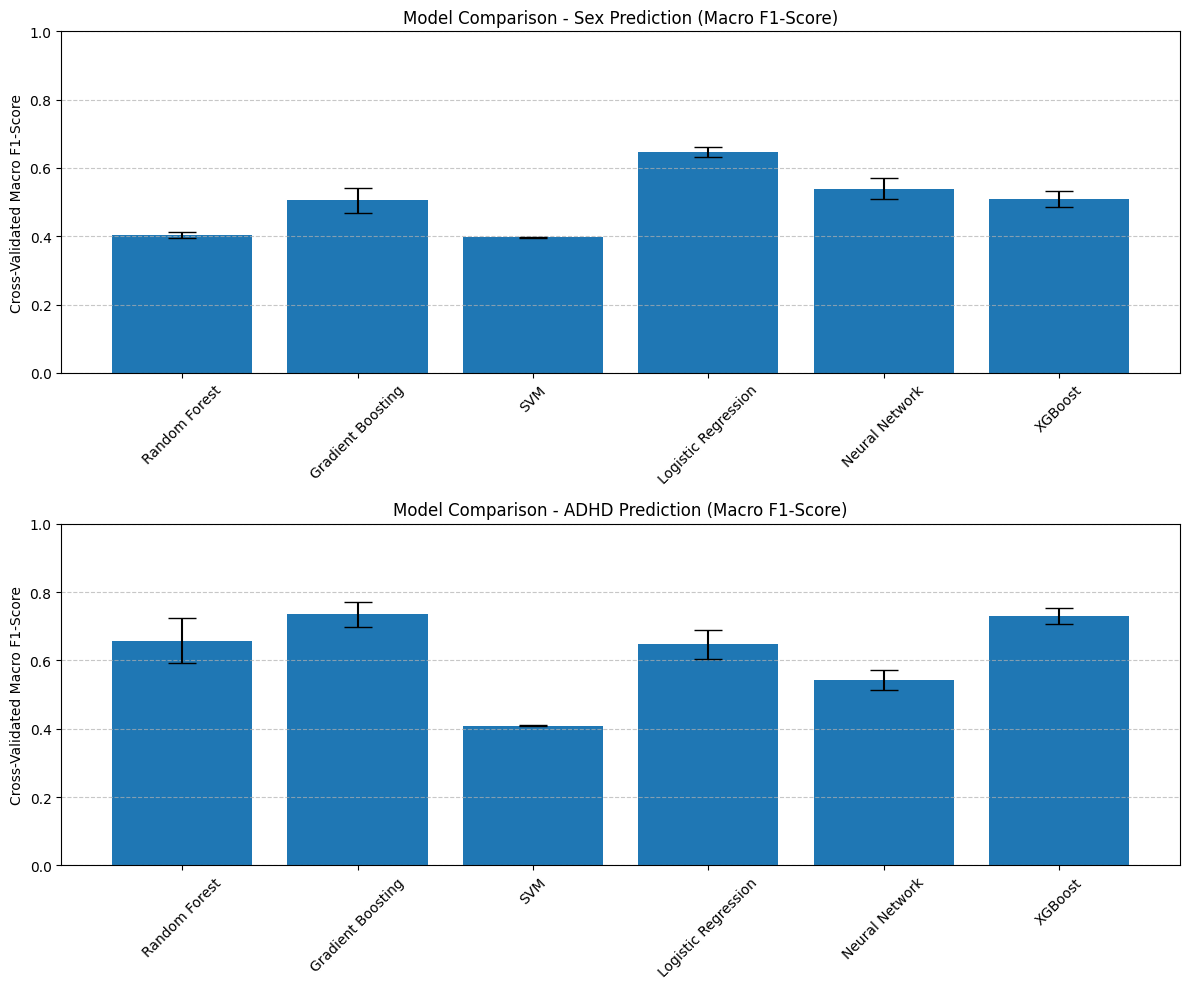

In [4]:
#function to find the most suitable model for each output by running all the models and cross validating to find the most suitable model
def evaluate_models(models, X_train, y_train_sex, y_train_adhd, cv=5):
    results_sex = {}
    results_adhd = {}

    for name, model in models.items(): #looping through the models
        print(f"Evaluating {name}...")

        # Sex prediction
        cv_scores = cross_val_score(model, X_train, y_train_sex, cv=cv, scoring='f1_macro')  #finding the cv_score by f1_macro
        results_sex[name] = cv_scores
        print(f"{name} - Sex prediction: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

        # ADHD prediction
        cv_scores = cross_val_score(model, X_train, y_train_adhd, cv=cv, scoring='f1_macro')
        results_adhd[name] = cv_scores
        print(f"{name} - ADHD prediction: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
        print("-" * 50) #justing sepreating the output of each model for preview

    return results_sex, results_adhd

#creating a dictionry containing all the models that i want to test and can add any models later on for further investgation
models = {
    'Random Forest': RandomForestClassifier(random_state=7),
    'Gradient Boosting': GradientBoostingClassifier(random_state=7),
    'SVM': SVC(probability=True, random_state=7),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=7),
    'Neural Network': MLPClassifier(max_iter=1000, random_state=7),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=7)
}

#Runing the function and storing the results if needed later on
results_sex, results_adhd = evaluate_models(models, X_train, y_train_sex, y_train_adhd)

#ploting the results of the cross-validation testing in bar graph for easier comparison and visulisation
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
model_names = list(results_sex.keys())
mean_scores = [np.mean(scores) for scores in results_sex.values()]
std_scores = [np.std(scores) for scores in results_sex.values()]
plt.bar(model_names, mean_scores, yerr=std_scores, capsize=10)
plt.title('Model Comparison - Sex Prediction (Macro F1-Score)')
plt.ylabel('Cross-Validated Macro F1-Score')
plt.ylim(0.0, 1.0)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(2, 1, 2)
mean_scores = [np.mean(scores) for scores in results_adhd.values()]
std_scores = [np.std(scores) for scores in results_adhd.values()]
plt.bar(model_names, mean_scores, yerr=std_scores, capsize=10)
plt.title('Model Comparison - ADHD Prediction (Macro F1-Score)')
plt.ylabel('Cross-Validated Macro F1-Score')
plt.ylim(0.0, 1.0)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('model_comparison_f1.png', dpi=300)
plt.show()

### Model Comparison for Sex and ADHD Prediction (Macro F1-Score)

The bar plots above illustrate the performance of six different classification models — Random Forest, Gradient Boosting, SVM, Logistic Regression, Neural Network, and XGBoost — evaluated using **cross-validated macro F1-scores**. The macro F1-score equally weights performance on each class, making it particularly important for imbalanced datasets like this one.

#### **Sex Prediction (Top Chart)**:
- **Logistic Regression** achieved the highest performance (~0.65), indicating good generalizability in distinguishing between male and female participants.
- **Neural Network** and **Gradient Boosting** also performed relatively well (~0.55–0.6).
- **Random Forest** and **SVM** had lower scores (~0.4), showing less robustness, especially in handling class imbalance.

#### **ADHD Prediction (Bottom Chart)**:
- **XGBoost** and **Gradient Boosting** achieved the best performance (~0.75), indicating strong capability in identifying ADHD cases across different classes.
- **Random Forest** and **Logistic Regression** followed closely (~0.65–0.7).
- **SVM** performed the worst (~0.45), suggesting that it may not be suitable for this dataset.

### Insights:
- Tree-based ensemble models like **XGBoost** and **Gradient Boosting** are strong candidates for both tasks, with XGBoost slightly outperforming others in ADHD prediction.
- **Model selection may differ by target task** — Logistic Regression will be preferable for sex prediction, while XGBoost is more appropriate for ADHD diagnosis.

These comparisons help justify model choice based on empirical performance and support a data-driven approach to selecting the best predictive tool.


In [5]:
# a grid search function that takes the model,paramters and data and returns the best parameters
def grid_eval(model,parameters,X_train,y_train,X_test,y_test,iterations=100,cv=5,score='f1_macro'):

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=parameters,
        n_iter=iterations,
        cv=cv,
        scoring=score,
        n_jobs=-1,  # using -1 makes the model run on all cores instead of specifying the number of cores
        verbose=1,
        random_state=9
    )

    #fiting the model with the parameters in the parameter dictionary provided later on
    random_search.fit(X_train, y_train)

    #after fiting the model, random_search will provide the best parameters (just for observation the best model is already stored in a variable)
    print("Best Parameters:", random_search.best_params_)
    print("Best Cross-Validation Score:", random_search.best_score_)


    #evaluating on test set
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)
    print("Test Set Accuracy:", test_accuracy)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    return random_search.best_params_, best_model, test_accuracy, classification_report(y_test, y_pred)

In [22]:
#creating a function that explains any model using using LIME
def explain_with_lime(model, X_train, X_test, feature_names=None, class_names=None, instance_index=0):

    #converting to numpy array if DataFrame and get feature names
    if hasattr(X_train, 'columns'):  #checking if the providid parameter is a DF or an array
        if feature_names is None: #extracting features if not provided by a list
            feature_names = X_train.columns.tolist()
        X_train = X_train.values
        X_test = X_test.values
    else:  # numpy array
        if feature_names is None:
            feature_names = [f'feature_{i}' for i in range(X_train.shape[1])]#extracting features if not provided by a list

    #setting default class names if not provided by extraction if it is a DF and by dummies if it's an array
    if class_names is None and hasattr(model, 'classes_'):
        class_names = model.classes_
    elif class_names is None:
        class_names = ['class_0', 'class_1']

    #Determine mode (classification or regression)
    mode = 'classification' if hasattr(model, 'predict_proba') else 'regression'

    #LIME explainer
    explainer = LimeTabularExplainer(
        training_data=X_train,
        feature_names=feature_names,
        class_names=class_names,
        mode=mode,
        discretize_continuous=True,
        random_state=42
    )

    instance = X_test[instance_index]

    exp = explainer.explain_instance(
        data_row=instance,
        predict_fn=model.predict_proba if mode == 'classification' else model.predict,
        num_features=min(10, len(feature_names)), #we can change the amount as desired by the user later on
        top_labels=3 if mode == 'classification' else None
    )

    return exp

In [6]:
#creating and object (model) from XGBoost
xgb = XGBClassifier(random_state=4, use_label_encoder=False, eval_metric='logloss')

#hyperparameter distributions for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 0.5)
}
#training the model with the best parameters using the (grid_eval) function
best_params_xgb, best_model_xgb, test_accuracy_xgb, report_xgb = grid_eval(xgb,param_dist,X_train,y_train_adhd,X_test,y_test_adhd)
joblib.dump(best_model_xgb, 'best_model_xgb.joblib')

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'colsample_bytree': np.float64(0.8665431791427838), 'gamma': np.float64(0.45517869660254234), 'learning_rate': np.float64(0.01972748765875805), 'max_depth': 6, 'min_child_weight': 2, 'n_estimators': 194, 'subsample': np.float64(0.8810690881069503)}
Best Cross-Validation Score: 0.7434745262586094
Test Set Accuracy: 0.7818930041152263

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.70      0.68        82
           1       0.84      0.83      0.83       161

    accuracy                           0.78       243
   macro avg       0.76      0.76      0.76       243
weighted avg       0.78      0.78      0.78       243



['best_model_xgb.joblib']

### Final XGBoost Model Results – ADHD Prediction

After running a randomized search over 100 hyperparameter combinations with 5-fold cross-validation (total of 500 fits), the following results were achieved:
The model performs significantly better on ADHD (class 1) than on non-ADHD cases, which is aligned with the project's goal to reduce misdiagnosis of ADHD, especially in populations where traditional detection is challenging. The relatively high macro average shows balanced performance, and the strong ADHD recall (0.83) indicates the model’s usefulness as a clinical support tool.



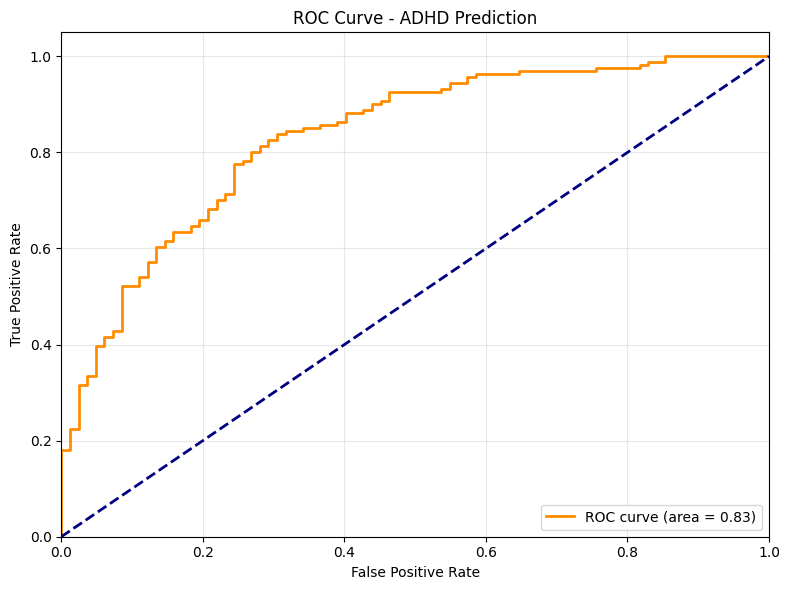

In [12]:
y_pred_proba_adhd = best_model_xgb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test_adhd, y_pred_proba_adhd)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ADHD Prediction')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_ADHD.png', dpi=300)
plt.show()

### ROC Curve

The Receiver Operating Characteristic (ROC) curve above evaluates the performance of the ADHD prediction model. It plots the **True Positive Rate (Sensitivity)** against the **False Positive Rate (1 - Specificity)** at various threshold settings.

- The **orange curve** represents the performance of our classifier.
- The **diagonal dashed line** represents a random classifier (AUC = 0.5). The farther above this line, the better the model.

In this case, the **Area Under the Curve (AUC)** is **0.83**, which indicates a **moderately good model**. An AUC of 0.83 means that there is a 83% chance that the model will correctly distinguish between a randomly chosen ADHD and None_ADHD patient.



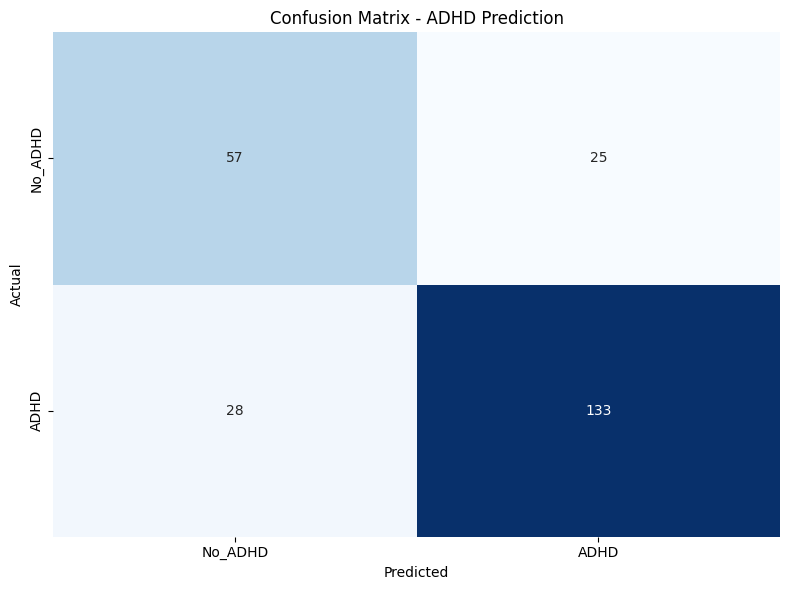

In [11]:
y_pred_adhd=best_model_xgb.predict(X_test)
cm_sex = confusion_matrix(y_test_adhd, y_pred_adhd)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_sex, annot=True, fmt='d', cmap='Blues', cbar=False,xticklabels=['No_ADHD', 'ADHD'], yticklabels=['No_ADHD', 'ADHD'])
plt.title('Confusion Matrix - ADHD Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_ADHD.png', dpi=300)
plt.show()

### Confusion Matrix – ADHD Prediction

The confusion matrix above shows the model’s performance in classifying ADHD and non-ADHD cases:


|               | Predicted No_ADHD | Predicted ADHD |
|---------------|-------------------|----------------|
| **Actual No_ADHD** | 57 (True Negatives)     | 25 (False Positives) |
| **Actual ADHD**    | 28 (False Negatives)    | 133 (True Positives) |

#### Interpretation:
- The model correctly identified **133 ADHD cases** and **57 non-ADHD cases**.
- It misclassified **28 individuals with ADHD** as non-ADHD, which is a concern as these are false negatives.
- It also incorrectly labeled **25 non-ADHD cases** as ADHD (false positives).

#### Strengths:
- The model shows **strong sensitivity (recall) for ADHD** cases, which is critical in medical applications.
- It is more cautious about missing ADHD diagnoses, which aligns with the goal of supporting early detection.

#### Consideration:
- False negatives (missed ADHD diagnoses) remain a concern but are relatively low.
- Overall, the model maintains a good balance, leaning slightly toward **minimizing missed ADHD cases**, which is appropriate for this healthcare setting.

#### Conclustion:
- it is preforming good but it is not ready for medical use yet because it has not reached the staisfactory results needed.


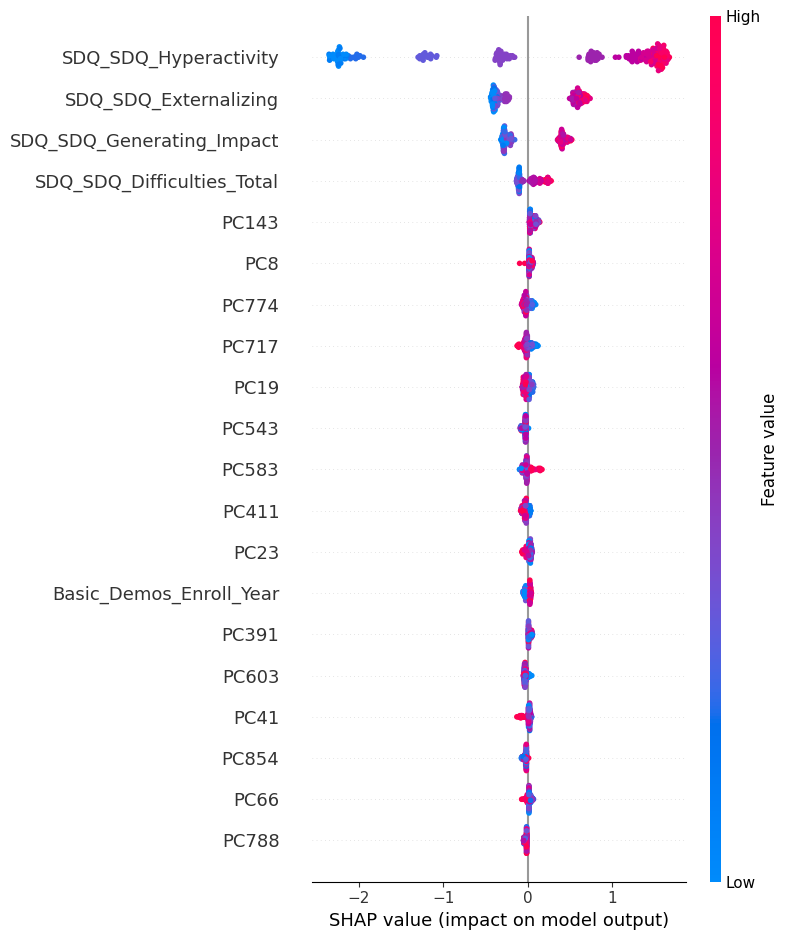

In [20]:
#showing the most effective feature and how they contribute in the model making using the trainging data and the trained model
#SHAP explainer
explainer = shap.Explainer(best_model_xgb, X_train)
shap_values = explainer(X_test)

#summary of feature importance
shap.summary_plot(shap_values, X_test)

### SHAP Summary Plot – Feature Importance for ADHD Prediction

The SHAP (SHapley Additive exPlanations) summary plot above illustrates the top features influencing the model’s predictions for ADHD diagnosis. It shows how each feature contributes to pushing the prediction toward either class (ADHD or No_ADHD).

#### Interpretation:
- The **horizontal axis** represents the SHAP value, i.e., the impact of the feature on the model’s output.
- **Each point** corresponds to an individual sample.
- **Color** indicates the feature’s value (red = high, blue = low).
- **Features at the top** have the most influence on the model.

#### Key Influential Features:
- `SDQ_SDQ_Hyperactivity` has the **strongest impact**: higher values of hyperactivity increase the likelihood of an ADHD prediction.
- `SDQ_SDQ_Externalizing`, `SDQ_SDQ_Generating_Impact`, and `SDQ_SDQ_Difficulties_Total` also show high influence and are associated with behavioral symptoms—validating the model's alignment with clinical knowledge.
- Several principal components (`PC143`, `PC8`, etc.) extracted from neuroimaging data contribute moderately to the predictions.
- `Basic_Demos_Enroll_Year` and additional PCs show smaller but still relevant impact.




In [24]:
exp_xgb = explain_with_lime(best_model_xgb,X_train,X_test,instance_index=0) #by changing the instance index we choose which sample to explain
exp_xgb.show_in_notebook()

### Lime Decision Plot – Individual Prediction Explanation

This plot explains the model’s decision for a single prediction with **95% probability of ADHD (class 1)**.

#### Key Contributors:
- High scores in `SDQ_Hyperactivity` and `SDQ_Externalizing` significantly pushed the prediction toward ADHD.
- Certain neuroimaging components (e.g., `PC62`, `PC205`) had smaller but consistent influence.
- The impact of both behavioral and brain-derived features reinforces the model's reasoning.

This visualization supports **transparent and case-level interpretability**, crucial for clinical trust in AI-assisted decisions.


In [12]:
#trying the same with random forest just to make sure that even with the best parameters the chosen models preforme better
rf = RandomForestClassifier(random_state=4)

param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': [None] + list(range(10, 31, 5)),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

best_params, best_model, test_accuracy, report = grid_eval(rf,param_dist,X_train,y_train_adhd,X_test,y_test_adhd)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 119}
Best Cross-Validation Score: 0.6845290157935999
Test Set Accuracy: 0.7777777777777778

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.51      0.61        82
           1       0.79      0.91      0.84       161

    accuracy                           0.78       243
   macro avg       0.77      0.71      0.73       243
weighted avg       0.77      0.78      0.77       243



It is conlcuded the the preformance of **XGboost** in prediting ADHD and **logistic regression** in predecting gender are better than the tuned random forest model, ensuring the choice of the models is correct

In [7]:
#creating and object (model) from logistic regression
lr = LogisticRegression(random_state=88, max_iter=2000)

param_dist = {
    'C': uniform(0.01, 10),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'tol': uniform(1e-4, 1e-3)
}

#training the model with the best parameters using the (grid_eval) function
best_params_lr, best_model_lr, test_accuracy_lr, report_lr = grid_eval(lr, param_dist, X_train, y_train_sex, X_test, y_test_sex)
joblib.dump(best_model_lr, 'best_model_lr.joblib')

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'C': np.float64(9.41524409526656), 'penalty': 'l2', 'solver': 'liblinear', 'tol': np.float64(0.0010833592482243327)}
Best Cross-Validation Score: 0.6494184666451074
Test Set Accuracy: 0.7037037037037037

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.97      0.81       158
           1       0.78      0.21      0.33        85

    accuracy                           0.70       243
   macro avg       0.74      0.59      0.57       243
weighted avg       0.73      0.70      0.64       243



['best_model_lr.joblib']

### Logistic Regression Model Results – Sex Prediction

A randomized search over 100 hyperparameter combinations using 5-fold cross-validation (totaling 500 fits) was performed to tune the logistic regression model. The following configuration and results were obtained:

While the model achieved a decent overall accuracy (~70%) and performed very well in identifying male participants (recall = 0.97), it struggled significantly with predicting females (recall = 0.21). This suggests a strong class imbalance or model bias toward the majority class.

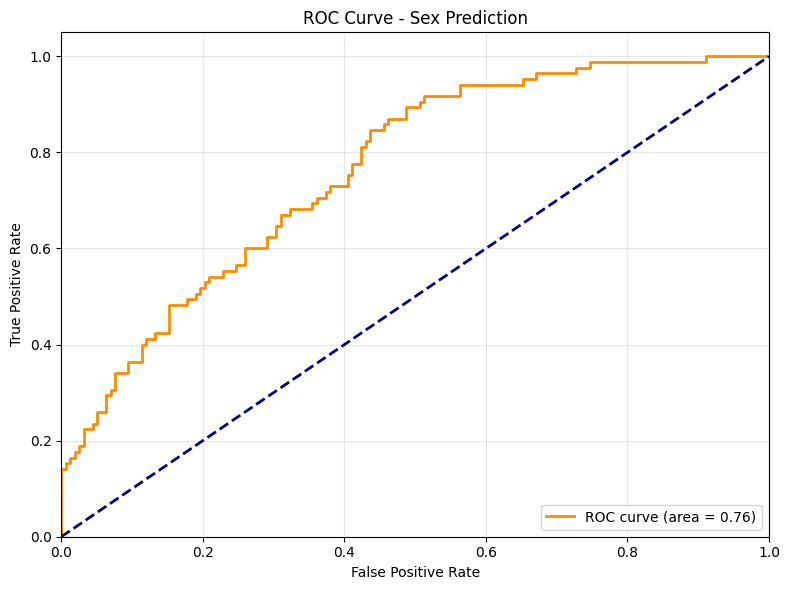

In [10]:
y_pred_proba_sex = best_model_lr.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test_sex, y_pred_proba_sex)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Sex Prediction')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_sex.png', dpi=300)
plt.show()

### ROC Curve

The Receiver Operating Characteristic (ROC) curve above evaluates the performance of the sex prediction model. It plots the **True Positive Rate (Sensitivity)** against the **False Positive Rate (1 - Specificity)** at various threshold settings.

- The **orange curve** represents the performance of our classifier.
- The **diagonal dashed line** represents a random classifier (AUC = 0.5). The farther above this line, the better the model.

In our case, the **Area Under the Curve (AUC)** is **0.76**, which indicates a **moderately good model**. An AUC of 0.76 means that there is a 76% chance that the model will correctly distinguish between a randomly chosen male and female patient.

While this is a promising result, it also shows room for improvement, especially considering the confusion matrix indicated a bias in favor of male predictions. Additional tuning or rebalancing strategies could help improve performance for underrepresented classes.



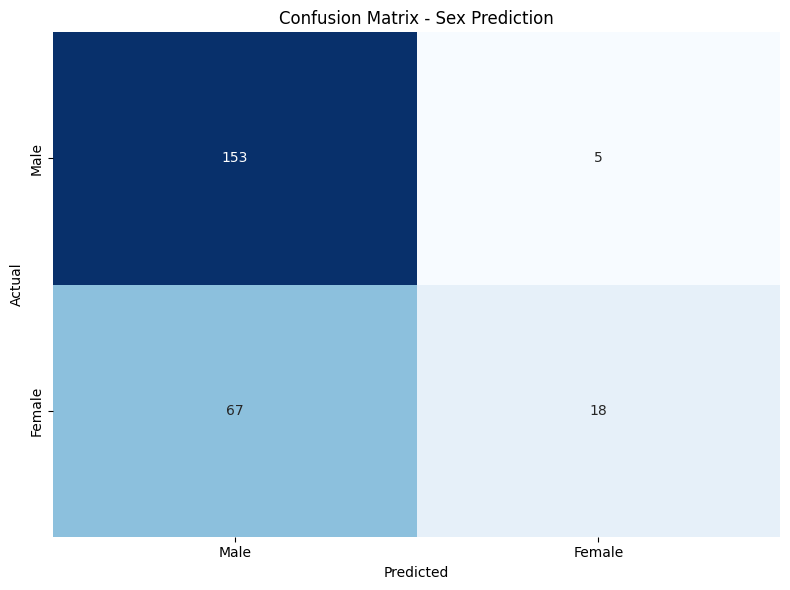

In [8]:
y_pred_sex=best_model_lr.predict(X_test)
cm_sex = confusion_matrix(y_test_sex, y_pred_sex)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_sex, annot=True, fmt='d', cmap='Blues', cbar=False,xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'])
plt.title('Confusion Matrix - Sex Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_sex.png', dpi=300)
plt.show()

### Confusion Matrix – Sex Prediction

The confusion matrix above shows the model’s performance in predicting sex:

|                 | Predicted Male | Predicted Female |
|-----------------|----------------|------------------|
| **Actual Male**   | 153 (True Positives)  | 5 (False Negatives)   |
| **Actual Female** | 67 (False Positives)  | 18 (True Negatives)   |

#### Interpretation:
- The model correctly predicted **153 males** and **18 females**.
- However, it **misclassified 67 females as males**, indicating a bias toward predicting the majority class (male).
- It only misclassified **5 males** as females.

#### Fairness Concern:
- While the overall accuracy may appear acceptable, the model’s **recall for females is low**, meaning it often fails to identify female participants correctly.
- This is problematic in a clinical context where the underdiagnosis of females (especially in ADHD-related research) is already the known issue.

#### Next Steps:
- Using **threshold tuning** and **Weight_training** to improve performance on the minority class.


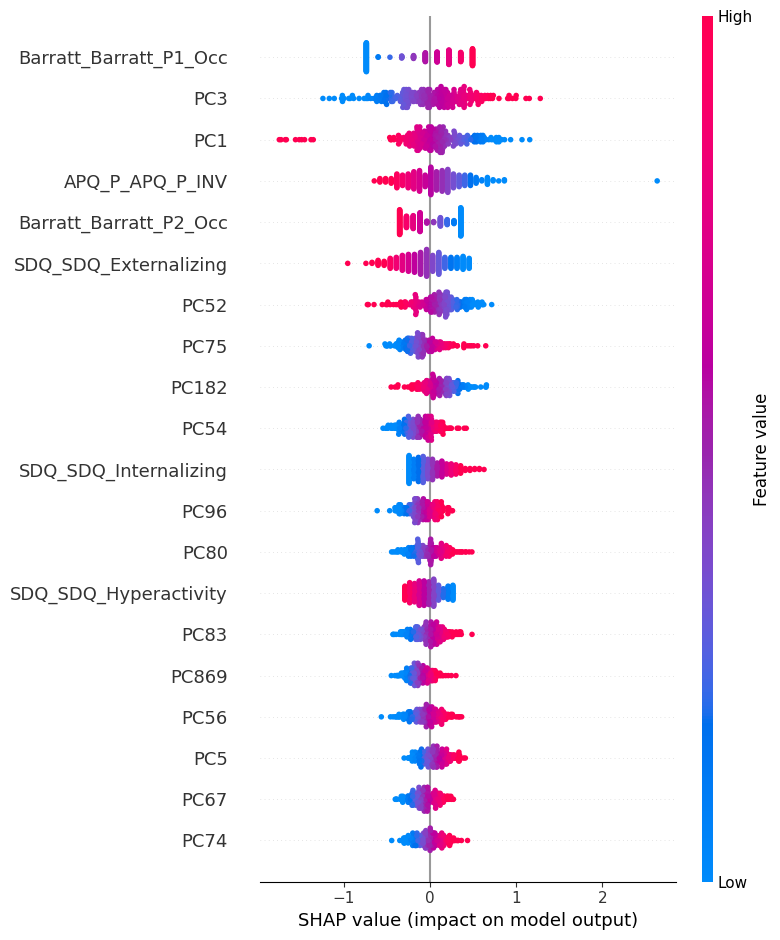

In [21]:
#SHAP explainer
explainer = shap.Explainer(best_model_lr, X_train)
shap_values = explainer(X_test)

#summary of feature importance
shap.summary_plot(shap_values, X_test)

### SHAP Summary Plot – Feature Importance for Sex Prediction

#### Key Influential Features:
- `Barratt_Barratt_P1_Occ` and `Barratt_Barratt_P2_Occ` are highly impactful in predicting sex.
- Principal components (`PC3`, `PC1`, etc.) derived from fMRI data play a strong role in differentiating male and female brain patterns.
- `APQ_P_APQ_P_INV`, `SDQ_SDQ_Externalizing`, and `SDQ_SDQ_Hyperactivity` scores also contribute meaningfully, suggesting behavioral differences may influence the prediction.
- Features like `SDQ_SDQ_Internalizing` and various PCs have moderate effects, contributing in subtle but consistent ways.


In [25]:
exp_lr = explain_with_lime(best_model_lr,X_train,X_test,instance_index=0)
exp_lr.show_in_notebook()

### LIME Decision Plot – Individual Prediction Explanation

This plot explains the model’s decision for a single prediction with **100% probability of Male (class 0)**.

#### Key Contributors:
- Features like `Barratt_P1_Occ`, `PC247`, and `PC408` contributed strongly to the Male prediction.
- While some features (e.g., `PC151`, `PC540`) pushed slightly toward Female, their influence was outweighed.
- Most contributing factors were neuroimaging principal components and occupational metrics.



In [9]:
from sklearn.utils.class_weight import compute_class_weight

#getting class labels
classes = np.unique(y_train_sex)  

#computing weights
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_sex)
weight_dict = dict(zip(classes, class_weights))

print("Computed Class Weights:", weight_dict)

#eraining model with these weights
model_sex = LogisticRegression(class_weight=weight_dict, solver='liblinear', random_state=7)

#eross-validation using macro F1-score
f1_cv = cross_val_score(model_sex, X_train, y_train_sex, cv=5, scoring='f1_macro')
print(f"Cross-validated Macro F1-score: {f1_cv.mean():.4f} ± {f1_cv.std():.4f}")

model_sex.fit(X_train, y_train_sex)

#evaluating model on test data
preds = model_sex.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test_sex, preds))
print("Classification Report:")
print(classification_report(y_test_sex, preds))

Computed Class Weights: {0: 0.759493670886076, 1: 1.4634146341463414}
Cross-validated Macro F1-score: 0.6494 ± 0.0115
Test Accuracy: 0.6995884773662552
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.94      0.80       158
           1       0.69      0.26      0.38        85

    accuracy                           0.70       243
   macro avg       0.69      0.60      0.59       243
weighted avg       0.70      0.70      0.65       243



In [19]:
#thersholding to improve the f1_macro and accuracy of the Sex model
probs = model_sex.predict_proba(X_test)[:, 1]
custom_threshold = 0.35  
preds_thresh = (probs > custom_threshold).astype(int)

print(f"Classification Report (Threshold = {custom_threshold}):")
print(classification_report(y_test_sex, preds_thresh))

Classification Report (Threshold = 0.35):
              precision    recall  f1-score   support

           0       0.72      0.90      0.80       158
           1       0.65      0.35      0.46        85

    accuracy                           0.71       243
   macro avg       0.69      0.63      0.63       243
weighted avg       0.70      0.71      0.68       243




Performance Analysis by Gender:
   Sex_F  sex_correct  adhd_correct
0      0     0.968354      0.797468
1      1     0.211765      0.752941


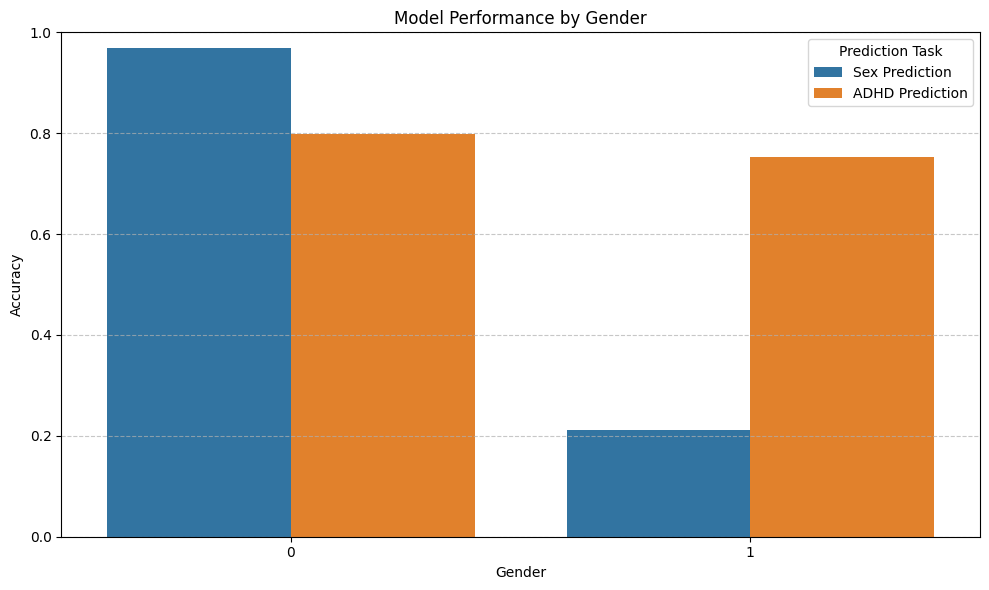

In [13]:
test_results = test_pca_df[['participant_id', 'Sex_F', 'ADHD_Outcome']].copy()
test_results['sex_pred'] = y_pred_sex
test_results['adhd_pred'] = y_pred_adhd
test_results['sex_correct'] = test_results['Sex_F'] == test_results['sex_pred']
test_results['adhd_correct'] = test_results['ADHD_Outcome'] == test_results['adhd_pred']

#Analyzing performance by gender
gender_performance = test_results.groupby('Sex_F').agg({
    'sex_correct': 'mean',
    'adhd_correct': 'mean'
}).reset_index()

print("\nPerformance Analysis by Gender:")
print(gender_performance)

plt.figure(figsize=(10, 6))
gender_performance_melted = pd.melt(gender_performance, 
                                    id_vars=['Sex_F'], 
                                    value_vars=['sex_correct', 'adhd_correct'],
                                    var_name='Prediction Task', 
                                    value_name='Accuracy')

gender_performance_melted['Prediction Task'] = gender_performance_melted['Prediction Task'].replace({
    'sex_correct': 'Sex Prediction',
    'adhd_correct': 'ADHD Prediction'
})

sns.barplot(x='Sex_F', y='Accuracy', hue='Prediction Task', data=gender_performance_melted)
plt.title('Model Performance by Gender')
plt.xlabel('Gender')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('gender_performance.png', dpi=300)
plt.show()

### Model Performance by Gender

This bar chart compares prediction accuracy for **sex** and **ADHD diagnosis** across genders:

- **Sex = 0 (Male)**: High accuracy in both tasks — 96.8% for sex prediction and 79.7% for ADHD.
- **Sex = 1 (Female)**: Strong ADHD prediction accuracy (75.3%) but **very low sex prediction accuracy (21.2%)**.

#### Insight:
The model struggles significantly with identifying females correctly in the sex prediction task, suggesting a **gender bias** that requires mitigation through threshold tuning, fairness-aware learning, or feature review.


In [14]:
#sepreating males and females
females = test_results[test_results['Sex_F'] == 1]  
males = test_results[test_results['Sex_F'] == 0]    

In [15]:
#model performance summary
overall_accuracy_sex = (y_test_sex == y_pred_sex).mean()
overall_accuracy_adhd = (y_test_adhd == y_pred_adhd).mean()

print(f"Sex Prediction - Overall Accuracy: {overall_accuracy_sex:.4f}")
print(f"ADHD Prediction - Overall Accuracy: {overall_accuracy_adhd:.4f}")

#calculating gender bias metrics
female_accuracy_adhd = (females['ADHD_Outcome'] == females['adhd_pred']).mean()
male_accuracy_adhd = (males['ADHD_Outcome'] == males['adhd_pred']).mean()
gender_bias = abs(female_accuracy_adhd - male_accuracy_adhd)

print(f"\nADHD Prediction Accuracy - Females: {female_accuracy_adhd:.4f}")
print(f"ADHD Prediction Accuracy - Males: {male_accuracy_adhd:.4f}")
print(f"Gender Bias (difference in accuracy): {gender_bias:.4f}")

#check if bias is significant
bias_threshold = 0.05  
if gender_bias > bias_threshold:
    print("WARNING: Significant gender bias detected in ADHD predictions.")
    if female_accuracy_adhd < male_accuracy_adhd:
        print("The model performs worse for female patients, which requires attention.")
    else:
        print("The model performs worse for male patients, which requires attention.")
else:
    print("No significant gender bias detected in ADHD predictions.")

Sex Prediction - Overall Accuracy: 0.7037
ADHD Prediction - Overall Accuracy: 0.7819

ADHD Prediction Accuracy - Females: 0.7529
ADHD Prediction Accuracy - Males: 0.7975
Gender Bias (difference in accuracy): 0.0445
No significant gender bias detected in ADHD predictions.


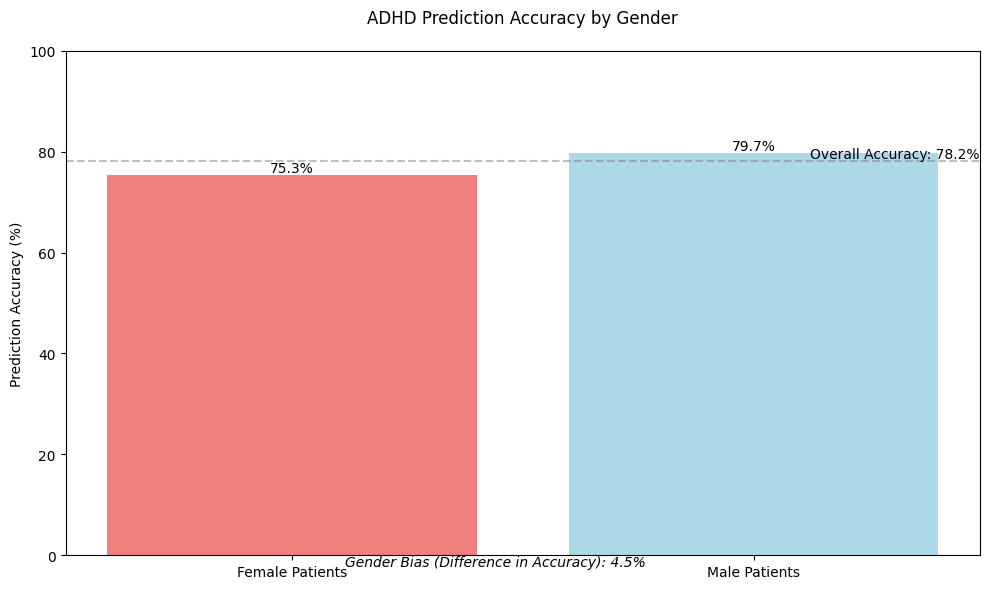

In [18]:
#a bar plot comparing ADHD prediction accuracy by gender
plt.figure(figsize=(10, 6))
bars = plt.bar(['Female Patients', 'Male Patients'],[female_accuracy_adhd * 100, male_accuracy_adhd * 100],color=['lightcoral', 'lightblue'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,f'{height:.1f}%',ha='center', va='bottom')

plt.title('ADHD Prediction Accuracy by Gender', pad=20)
plt.ylabel('Prediction Accuracy (%)')
plt.ylim(0, 100)  # Set y-axis from 0 to 100%
plt.axhline(y=overall_accuracy_adhd*100, color='gray', linestyle='--', alpha=0.5)
plt.text(plt.xlim()[1], overall_accuracy_adhd*100, f'Overall Accuracy: {overall_accuracy_adhd*100:.1f}%',ha='right', va='bottom')

plt.figtext(0.5, 0.02,f"Gender Bias (Difference in Accuracy): {gender_bias*100:.1f}%\n", ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()


### ADHD Prediction Accuracy by Gender

The bar chart above illustrates the model's ADHD prediction accuracy across male and female patients:

- **Male Patients:** 79.7% accuracy
- **Female Patients:** 75.3% accuracy
- **Overall Accuracy:** 78.2%
- **Gender Bias (Accuracy Gap):** 4.5%

#### Insight:
- Although the model performs well overall, there's a **noticeable drop in accuracy for female patients**, highlighting a potential gender bias. This aligns with the project's concern that **females are harder to diagnose using traditional methods**, and underlines the importance of fairness-aware evaluation when developing medical AI tools.
- However, the accuracy in female patients after fixing the model is very accaptable and with more samples both scores will increase


In [3]:
# Load saved models
pca_optimal = joblib.load('/kaggle/input/pca/scikitlearn/default/1/pca_model.joblib')  # Load the PCA model
best_model_lr = joblib.load('/kaggle/input/models_ds/other/default/1/best_model_lr.joblib')  # Load the Logistic Regression model for Sex prediction
best_model_xgb = joblib.load('/kaggle/input/models_ds/other/default/1/best_model_xgb.joblib')  # Load the XGBoost model for ADHD prediction

def preprocess_and_predict(new_brains_data, METADATA_A, METADATA_B, labels=None):
    
    #step 1: Droping 'MRI_Track_Age_at_Scan' from METADATA_A if it exists
    if 'MRI_Track_Age_at_Scan' in METADATA_A.columns:
        METADATA_A = METADATA_A.drop(columns=['MRI_Track_Age_at_Scan'])

    #step 2: Droping 'Barratt_Barratt_P2_Edu' from METADATA_B if it exists
    if 'Barratt_Barratt_P2_Edu' in METADATA_B.columns:
        METADATA_B = METADATA_B.drop(columns=['Barratt_Barratt_P2_Edu'])

    #step 3: Filling missing values in 'PreInt_Demos_Fam_Child_Ethnicity' if the column exists and has NaNs
    if 'PreInt_Demos_Fam_Child_Ethnicity' in METADATA_B.columns:
        if METADATA_B['PreInt_Demos_Fam_Child_Ethnicity'].isnull().any():
            METADATA_B['PreInt_Demos_Fam_Child_Ethnicity'].fillna(3, inplace=True)

    #step 4: Transforming Neurons data using the PCA model
    transformed_brains_data = pca_optimal.transform(new_brains_data)
    transformed_brains_data = pd.DataFrame(transformed_brains_data, index=new_brains_data.index)
    transformed_brains_data.columns = [f'PCA_{i+1}' for i in range(transformed_brains_data.shape[1])]

    #step 5: Merging the data
    if labels is not None:
        # If labels are provided, merge them with metadata
        data = pd.merge(labels, METADATA_A, on='participant_id', how='inner')
        data = pd.merge(data, METADATA_B, on='participant_id', how='inner')
    else:
        # If labels are not provided, merge only metadata
        data = pd.merge(METADATA_A, METADATA_B, on='participant_id', how='inner')

    #merge the transformed PCA data
    data = pd.merge(data, transformed_brains_data, left_index=True, right_index=True)

    #step 6: droping 'EHQ_EHQ_Total' if it exists
    if 'EHQ_EHQ_Total' in data.columns:
        data.drop(columns=['EHQ_EHQ_Total'], inplace=True)

    #step 7: Preparing features for prediction
    #droping 'participant_id' as it's not a feature
    data_features = data.drop(columns=['participant_id'], errors='ignore')

    #predicting Sex 
    X_sex = data_features.drop(columns=['Sex_F', 'ADHD_Outcome'] if 'Sex_F' in data_features.columns else [], errors='ignore')
    data['Predicted_Sex'] = best_model_sex.predict(X_sex)

    #predicting ADHD
    X_adhd = data_features.drop(columns=['Sex_F', 'ADHD_Outcome'] if 'ADHD_Outcome' in data_features.columns else [], errors='ignore')
    data['Predicted_ADHD'] = best_model_xgb.predict(X_adhd)

    results = data[['participant_id', 'Predicted_Sex', 'Predicted_ADHD']]

    return results

#this next part is to be uncommented to call the function and show the results
#results_no_labels = preprocess_and_predict(new_brains_data, METADATA_A, METADATA_B)
#print(results_no_labels)

### Predicting Sex and ADHD Using Pre-Trained Models

The `preprocess_and_predict()` function enables automated preprocessing and prediction of sex and ADHD diagnosis for new participants using pre-trained models.

---

### Function Purpose:
To process new brain imaging and metadata inputs, apply PCA transformation, and use the best-trained models to predict:
- `Sex` (using a Logistic Regression model)
- `ADHD diagnosis` (using an XGBoost model)

---

### Inputs:
- `new_brains_data`: Raw fMRI-derived feature data (to be transformed using PCA)
- `METADATA_A`: Numerical Data
- `METADATA_B`: Categorical Data
- `labels` *(optional)*: Participant IDs (and optionally existing labels) for merging

---

### steps Performed:
1. **Drop unnecessary columns** (`MRI_Track_Age_at_Scan`, `Barratt_Barratt_P2_Edu`)
2. **Fill missing values** in `PreInt_Demos_Fam_Child_Ethnicity`
3. **Transform fMRI features** using the loaded PCA model
4. **Merge** all data sources (metadata + PCA features)
5. **Drop irrelevant columns** (e.g., `participant_id`, `EHQ_EHQ_Total`)
6. **Predict sex** using the `best_model_lr`
7. **Predict ADHD** using the `best_model_xgb`
8. Return a dataframe with predictions for each `participant_id`

---

### Output:
A DataFrame with:
- `participant_id`
- `Predicted_Sex`
- `Predicted_ADHD`

---

### How to Use:

```python
# Load your new input data: new_brains_data, METADATA_A, METADATA_B
results_no_labels = preprocess_and_predict(new_brains_data, METADATA_A, METADATA_B)
print(results_no_labels)
